In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/k-67-medical-image-segmentation/Dataset/Test/Image/0001226.jpg
/kaggle/input/k-67-medical-image-segmentation/Dataset/Test/Image/0001126.jpg
/kaggle/input/k-67-medical-image-segmentation/Dataset/Test/Image/0001208.jpg
/kaggle/input/k-67-medical-image-segmentation/Dataset/Test/Image/0001166.jpg
/kaggle/input/k-67-medical-image-segmentation/Dataset/Test/Image/0001102.jpg
/kaggle/input/k-67-medical-image-segmentation/Dataset/Test/Image/0001157.jpg
/kaggle/input/k-67-medical-image-segmentation/Dataset/Test/Image/0001228.jpg
/kaggle/input/k-67-medical-image-segmentation/Dataset/Test/Image/0001115.jpg
/kaggle/input/k-67-medical-image-segmentation/Dataset/Test/Image/0001183.jpg
/kaggle/input/k-67-medical-image-segmentation/Dataset/Test/Image/0001131.jpg
/kaggle/input/k-67-medical-image-segmentation/Dataset/Test/Image/0001100.jpg
/kaggle/input/k-67-medical-image-segmentation/Dataset/Test/Image/0001122.jpg
/kaggle/input/k-67-medical-image-segmentation/Dataset/Test/Image/0001182.jpg

In [2]:
from PIL import Image, ImageEnhance
import os

# Directory containing the images
input_dir = '/kaggle/input/k-67-medical-image-segmentation/Dataset/Train/Image'

# Output directory to save high contrast images
output_dir = 'high contrast 2'

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Iterate over all files in the input directory
for filename in os.listdir(input_dir):
    # Full path to the image file
    image_path = os.path.join(input_dir, filename)
    
    # Check if it's an image file (you can filter by extensions like .jpg, .png, etc.)
    if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
        # Open the image
        with Image.open(image_path) as img:
            # Convert image to grayscale
            gray_img = img.convert('L')
            
            # Enhance the contrast
            enhancer = ImageEnhance.Contrast(gray_img)
            high_contrast_img = enhancer.enhance(2)  # You can adjust the factor for more/less contrast
            
            # Save the high contrast image in the output folder
            high_contrast_img.save(os.path.join(output_dir, filename))

print("All images have been processed and saved to the 'high contrast' folder.")


All images have been processed and saved to the 'high contrast' folder.


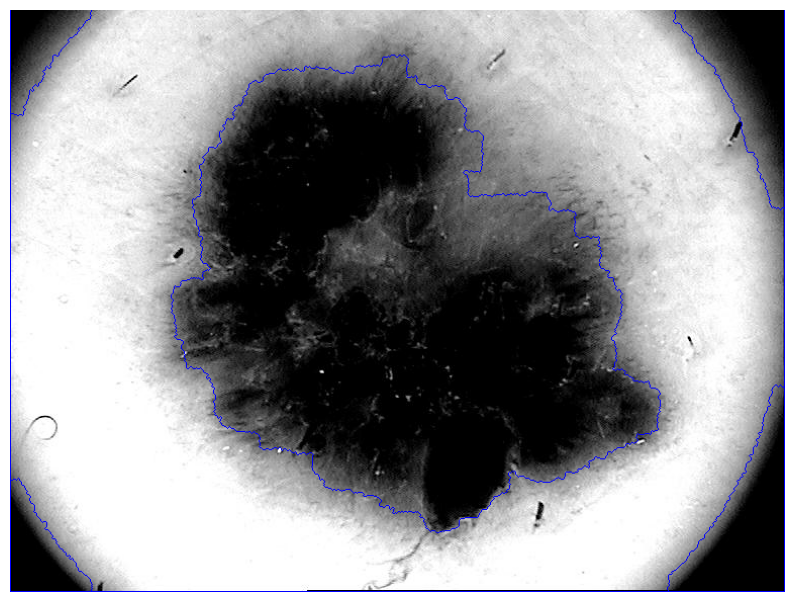

In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load image
img = cv2.imread('/kaggle/working/high contrast 2/0000213.jpg')

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply thresholding
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Remove noise with morphological opening
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=9)

# Sure background area
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Finding sure foreground area using distance transform
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.01*dist_transform.max(), 255, 0)

# Finding unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labelling
ret, markers = cv2.connectedComponents(sure_fg)

# Add one to all labels so that sure background is not 0, but 1
markers = markers + 1

# Mark the region of unknown with zero
markers[unknown == 255] = 0

# Apply watershed
markers = cv2.watershed(img, markers)
img[markers == -1] = [255, 0, 0]  # Mark boundaries in red

# Show result
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

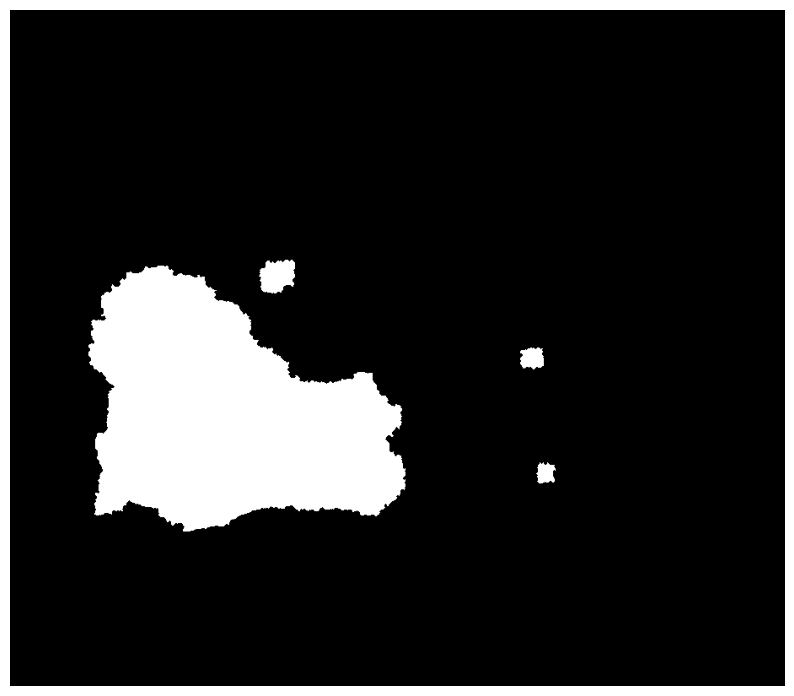

In [4]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load image
img = cv2.imread('/kaggle/working/high contrast 2/0000173.jpg')

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply thresholding
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Remove noise with morphological opening
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=9)

# Sure background area
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Finding sure foreground area using distance transform
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.01*dist_transform.max(), 255, 0)

# Finding unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labelling
ret, markers = cv2.connectedComponents(sure_fg)

# Add one to all labels so that sure background is not 0, but 1
markers = markers + 1

# Mark the region of unknown with zero
markers[unknown == 255] = 0

# Apply watershed
markers = cv2.watershed(img, markers)

# Prepare an empty mask for output
output_mask = np.zeros(gray.shape, dtype=np.uint8)

# Get unique region ids (ignore -1 which is boundary)
region_ids = np.unique(markers)
region_ids = region_ids[region_ids > 1]

h, w = gray.shape

# Check each region if it touches the border
for region_id in region_ids:
    region_mask = (markers == region_id).astype(np.uint8)
    # Find coordinates where this region exists
    ys, xs = np.where(region_mask)
    # If any pixel of this region touches the border, skip
    if (0 in xs) or (w-1 in xs) or (0 in ys) or (h-1 in ys):
        continue
    # Otherwise, fill this region as white in the output mask
    output_mask[markers == region_id] = 255

# Show result
plt.figure(figsize=(10,10))
plt.imshow(output_mask, cmap='gray')
plt.axis('off')
plt.show()

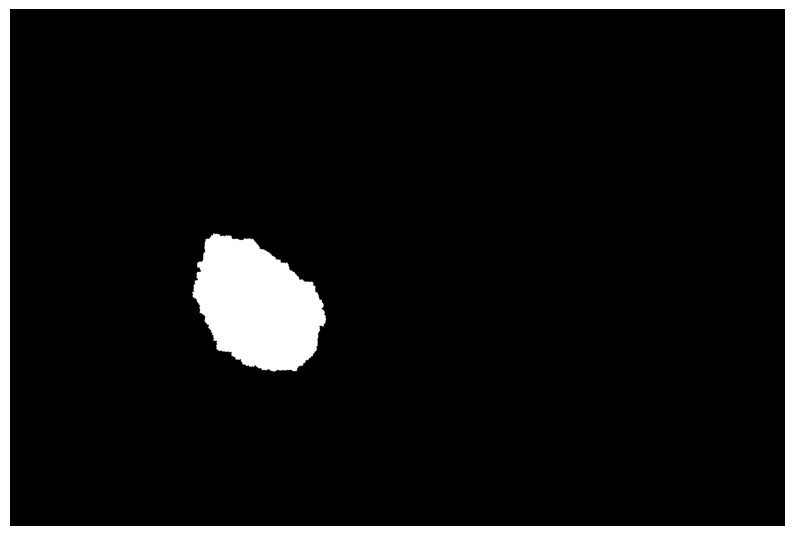

In [7]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load image
img = cv2.imread('/kaggle/working/high contrast 2/0001085.jpg')

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply thresholding
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Remove noise with morphological opening
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=9)

# Sure background area
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Finding sure foreground area using distance transform
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.01*dist_transform.max(), 255, 0)

# Finding unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labelling
ret, markers = cv2.connectedComponents(sure_fg)

# Add one to all labels so that sure background is not 0, but 1
markers = markers + 1

# Mark the region of unknown with zero
markers[unknown == 255] = 0

# Apply watershed
markers = cv2.watershed(img, markers)

# Prepare an empty mask for output
output_mask = np.zeros(gray.shape, dtype=np.uint8)

# Get unique region ids (ignore -1 which is boundary)
region_ids = np.unique(markers)
region_ids = region_ids[region_ids > 1]

h, w = gray.shape

# Check each region if it touches the border
for region_id in region_ids:
    region_mask = (markers == region_id).astype(np.uint8)
    ys, xs = np.where(region_mask)
    # If any pixel of this region touches the border, skip
    if (0 in xs) or (w-1 in xs) or (0 in ys) or (h-1 in ys):
        continue
    # Otherwise, fill this region as white in the output mask
    output_mask[markers == region_id] = 255

# --- Keep only the largest white area ---
# Label connected components in the mask (background=0)
num_labels, labels = cv2.connectedComponents(output_mask)

# Find the largest non-background region
max_area = 0
max_label = 0
for label in range(1, num_labels):  # skip background label 0
    area = np.sum(labels == label)
    if area > max_area:
        max_area = area
        max_label = label

# Create a final mask with only the largest region as white
final_mask = np.zeros_like(output_mask)
if max_label != 0:
    final_mask[labels == max_label] = 255

# Show result
plt.figure(figsize=(10,10))
plt.imshow(final_mask, cmap='gray')
plt.axis('off')
plt.show()

In [6]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt

# Input and output directories
input_dir = '/kaggle/working/high contrast 2'
output_dir = '/kaggle/working/mask'
os.makedirs(output_dir, exist_ok=True)

# Process all jpg images in the input directory
for filename in os.listdir(input_dir):
    if filename.lower().endswith('.jpg'):
        img_path = os.path.join(input_dir, filename)
        img = cv2.imread(img_path)

        if img is None:
            print(f"Could not read {img_path}. Skipping...")
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        kernel = np.ones((3,3), np.uint8)
        opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=9)

        sure_bg = cv2.dilate(opening, kernel, iterations=3)

        dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
        ret, sure_fg = cv2.threshold(dist_transform, 0.01*dist_transform.max(), 255, 0)

        sure_fg = np.uint8(sure_fg)
        unknown = cv2.subtract(sure_bg, sure_fg)

        ret, markers = cv2.connectedComponents(sure_fg)
        markers = markers + 1
        markers[unknown == 255] = 0

        cv2.watershed(img, markers)

        output_mask = np.zeros(gray.shape, dtype=np.uint8)

        region_ids = np.unique(markers)
        region_ids = region_ids[region_ids > 1]

        h, w = gray.shape

        for region_id in region_ids:
            region_mask = (markers == region_id).astype(np.uint8)
            ys, xs = np.where(region_mask)
            if (0 in xs) or (w-1 in xs) or (0 in ys) or (h-1 in ys):
                continue
            output_mask[markers == region_id] = 255

        num_labels, labels = cv2.connectedComponents(output_mask)
        max_area = 0
        max_label = 0
        for label in range(1, num_labels):
            area = np.sum(labels == label)
            if area > max_area:
                max_area = area
                max_label = label

        final_mask = np.zeros_like(output_mask)
        if max_label != 0:
            final_mask[labels == max_label] = 255

        # Save the mask
        output_path = os.path.join(output_dir, filename)
        cv2.imwrite(output_path, final_mask)

        print(f"Processed and saved mask for {filename}.")

print("All images processed. Masks are saved in the 'mask' folder.")

Processed and saved mask for 0000671.jpg.
Processed and saved mask for 0000018.jpg.
Processed and saved mask for 0000876.jpg.
Processed and saved mask for 0000272.jpg.
Processed and saved mask for 0000112.jpg.
Processed and saved mask for 0000344.jpg.
Processed and saved mask for 0000700.jpg.
Processed and saved mask for 0000133.jpg.
Processed and saved mask for 0000149.jpg.
Processed and saved mask for 0000082.jpg.
Processed and saved mask for 0000195.jpg.
Processed and saved mask for 0000190.jpg.
Processed and saved mask for 0000438.jpg.
Processed and saved mask for 0000824.jpg.
Processed and saved mask for 0000411.jpg.
Processed and saved mask for 0000220.jpg.
Processed and saved mask for 0000963.jpg.
Processed and saved mask for 0000131.jpg.
Processed and saved mask for 0000811.jpg.
Processed and saved mask for 0001008.jpg.
Processed and saved mask for 0000012.jpg.
Processed and saved mask for 0000951.jpg.
Processed and saved mask for 0000427.jpg.
Processed and saved mask for 00005

In [8]:
import os
import shutil
import random

# Directories
images_dir = '/kaggle/input/k-67-medical-image-segmentation/Dataset/Train/Image'
masks_dir = '/kaggle/working/mask'

output_base = '/kaggle/working/split_data'
train_image_dir = os.path.join(output_base, 'train', 'images')
train_mask_dir = os.path.join(output_base, 'train', 'masks')
test_image_dir = os.path.join(output_base, 'test', 'images')
test_mask_dir = os.path.join(output_base, 'test', 'masks')

# Make output directories
for d in [train_image_dir, train_mask_dir, test_image_dir, test_mask_dir]:
    os.makedirs(d, exist_ok=True)

# Get all image filenames that have a corresponding mask
image_files = sorted([f for f in os.listdir(images_dir) if f.lower().endswith('.jpg')])
mask_files = set(os.listdir(masks_dir))

paired_files = [f for f in image_files if f in mask_files]

# Split ratio
test_ratio = 0.2  # 20% for test, 80% for train
random.shuffle(paired_files)
split_idx = int(len(paired_files) * (1 - test_ratio))

train_files = paired_files[:split_idx]
test_files = paired_files[split_idx:]

# Copy files to the output directories
for split, files in [('train', train_files), ('test', test_files)]:
    for fname in files:
        img_src = os.path.join(images_dir, fname)
        mask_src = os.path.join(masks_dir, fname)
        img_dst = os.path.join(output_base, split, 'images', fname)
        mask_dst = os.path.join(output_base, split, 'masks', fname)
        shutil.copy(img_src, img_dst)
        shutil.copy(mask_src, mask_dst)

print(f"Train/Test split complete. {len(train_files)} train pairs and {len(test_files)} test pairs.")

Train/Test split complete. 869 train pairs and 218 test pairs.


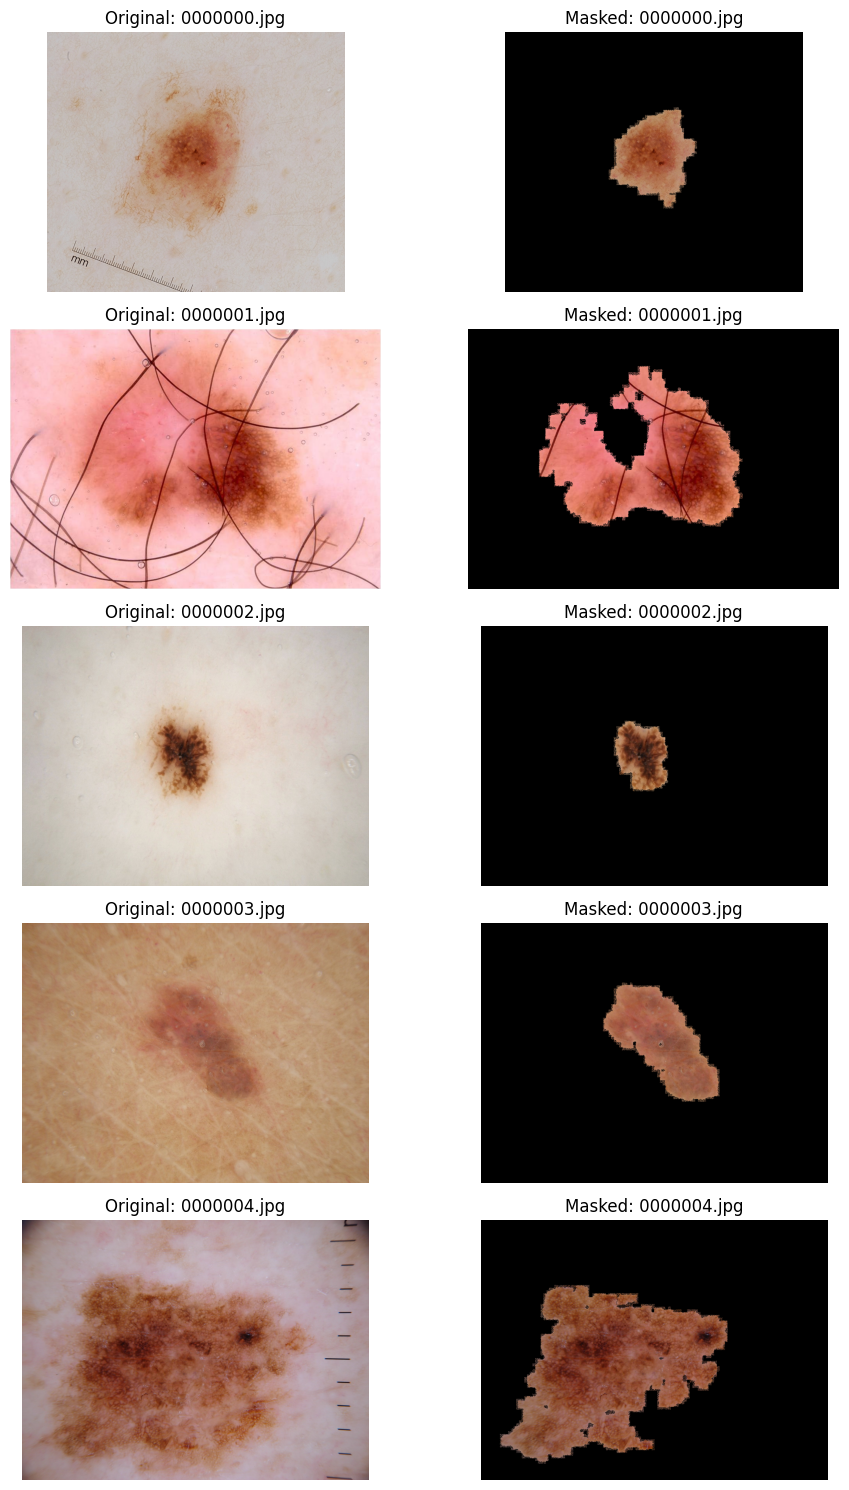

In [10]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# Directories
images_dir = '/kaggle/input/k-67-medical-image-segmentation/Dataset/Train/Image'
masks_dir = '/kaggle/working/mask'

# Get all image filenames that have a corresponding mask
image_files = sorted([f for f in os.listdir(images_dir) if f.lower().endswith('.jpg')])
mask_files = set(os.listdir(masks_dir))

paired_files = [f for f in image_files if f in mask_files]
num_to_show = min(5, len(paired_files))

plt.figure(figsize=(10, num_to_show * 3))

for i in range(num_to_show):
    fname = paired_files[i]
    img = cv2.imread(os.path.join(images_dir, fname))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(os.path.join(masks_dir, fname), cv2.IMREAD_GRAYSCALE)
    
    # Apply the mask: show only masked regions, rest set to black
    masked_img = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

    plt.subplot(num_to_show, 2, 2*i+1)
    plt.imshow(img_rgb)
    plt.title(f'Original: {fname}')
    plt.axis('off')
    
    plt.subplot(num_to_show, 2, 2*i+2)
    plt.imshow(masked_img)
    plt.title(f'Masked: {fname}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras import layers, models

2025-07-01 05:25:18.532585: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751347518.730926      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751347518.788564      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [12]:
class DataGenerator(Sequence):
    def __init__(self, images_dir, masks_dir, batch_size=8, img_size=(256, 256)):
        self.image_filenames = sorted([f for f in os.listdir(images_dir) if f.endswith('.jpg')])
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.batch_size = batch_size
        self.img_size = img_size

    def __len__(self):
        return int(np.ceil(len(self.image_filenames) / self.batch_size))

    def __getitem__(self, idx):
        batch_files = self.image_filenames[idx * self.batch_size : (idx + 1) * self.batch_size]
        X = []
        Y = []
        for fname in batch_files:
            img = cv2.imread(os.path.join(self.images_dir, fname))
            img = cv2.resize(img, self.img_size)
            img = img.astype(np.float32) / 255.0

            mask = cv2.imread(os.path.join(self.masks_dir, fname), cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, self.img_size)
            mask = (mask > 127).astype(np.float32)  # Binary mask

            X.append(img)
            Y.append(mask[..., np.newaxis])  # Add channel dimension

        return np.array(X), np.array(Y)

In [13]:
def unet(input_shape=(256,256,3)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(c4)

    # Decoder
    u5 = layers.UpSampling2D()(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(c5)

    u6 = layers.UpSampling2D()(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(32, 3, activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(32, 3, activation='relu', padding='same')(c6)

    u7 = layers.UpSampling2D()(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(16, 3, activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(16, 3, activation='relu', padding='same')(c7)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c7)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

In [14]:
img_size = (256, 256)
batch_size = 8

train_img_dir = '/kaggle/working/split_data/train/images'
train_mask_dir = '/kaggle/working/split_data/train/masks'
test_img_dir = '/kaggle/working/split_data/test/images'
test_mask_dir = '/kaggle/working/split_data/test/masks'

train_gen = DataGenerator(train_img_dir, train_mask_dir, batch_size, img_size)
test_gen = DataGenerator(test_img_dir, test_mask_dir, batch_size, img_size)

In [15]:
model = unet(input_shape=(img_size[0], img_size[1], 3))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=10  # you can increase this
)

I0000 00:00:1751347602.245313      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 256, 256, 3))
  warnings.warn(msg)
I0000 00:00:1751347610.522816     118 service.cc:148] XLA service 0x7c049005a200 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751347610.523628     118 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1751347611.255084     118 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/109 ━━━━━━━━━━━━━━━━━━━━ 24:36 14s/step - accuracy: 0.7996 - loss: 0.6875

I0000 00:00:1751347617.776457     118 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


109/109 ━━━━━━━━━━━━━━━━━━━━ 47s 308ms/step - accuracy: 0.8343 - loss: 0.3799 - val_accuracy: 0.8956 - val_loss: 0.2542
Epoch 2/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 232ms/step - accuracy: 0.8665 - loss: 0.3144 - val_accuracy: 0.9146 - val_loss: 0.2293
Epoch 3/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 234ms/step - accuracy: 0.9112 - loss: 0.2268 - val_accuracy: 0.9179 - val_loss: 0.2302
Epoch 4/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 24s 221ms/step - accuracy: 0.9137 - loss: 0.2342 - val_accuracy: 0.9240 - val_loss: 0.2094
Epoch 5/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 224ms/step - accuracy: 0.9173 - loss: 0.2226 - val_accuracy: 0.9147 - val_loss: 0.2257
Epoch 6/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 24s 224ms/step - accuracy: 0.9150 - loss: 0.2214 - val_accuracy: 0.9242 - val_loss: 0.2049
Epoch 7/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 229ms/step - accuracy: 0.9175 - loss: 0.2166 - val_accuracy: 0.9216 - val_loss: 0.2136
Epoch 8/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 227ms/step - accuracy: 0.9224 - loss: 0.2071 - val

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


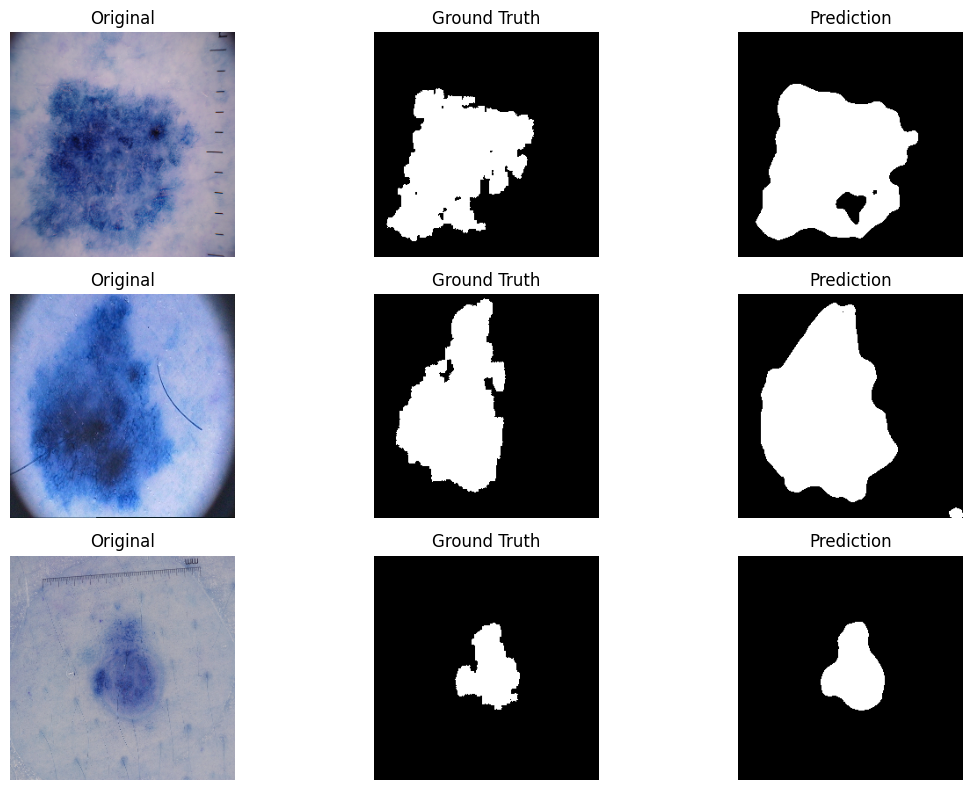

In [21]:
import matplotlib.pyplot as plt

X_val, Y_val = test_gen[0]  # Get a batch from validation

preds = model.predict(X_val)
preds = (preds > 0.5).astype(np.uint8)

plt.figure(figsize=(12, 8))
for i in range(3):
    plt.subplot(3, 3, 3*i+1)
    plt.imshow(X_val[i])
    plt.title('Original')
    plt.axis('off')
    plt.subplot(3, 3, 3*i+2)
    plt.imshow(Y_val[i].squeeze(), cmap='gray')
    plt.title('Ground Truth')
    plt.axis('off')
    plt.subplot(3, 3, 3*i+3)
    plt.imshow(preds[i].squeeze(), cmap='gray')
    plt.title('Prediction')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Path to the new image (change this as needed)
img_path = '/kaggle/input/ferererere/testing .jpg'

In [23]:
img_size = (256, 256)  # Use your model's input size

# Read and resize image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, img_size)
img_input = img_resized.astype(np.float32) / 255.0
img_input = np.expand_dims(img_input, axis=0)  # Shape: (1, H, W, 3)

In [38]:
# Predict using your trained model
pred_mask = model.predict(img_input)
pred_mask = (pred_mask[0, ..., 0] > 0.5).astype(np.uint8)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


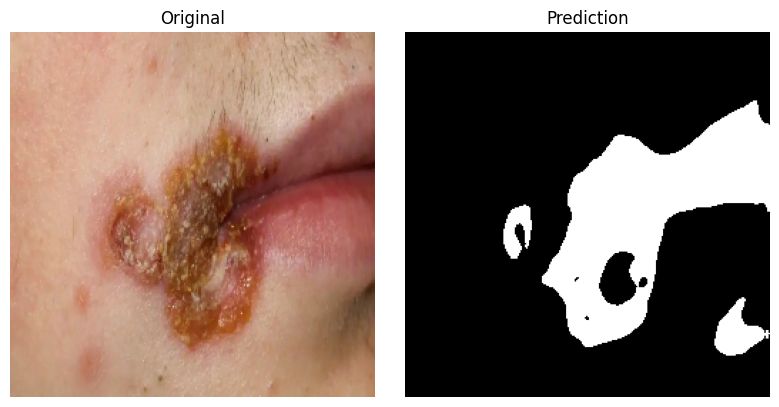

In [39]:
plt.figure(figsize=(12, 4))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(img_resized)
plt.title('Original')
plt.axis('off')


# Predicted mask
plt.subplot(1, 3, 2)
plt.imshow(pred_mask, cmap='gray')
plt.title('Prediction')
plt.axis('off')

plt.tight_layout()
plt.show()

In [41]:
img_path = '/kaggle/input/testing2/testing2.jpeg'
img_size = (256, 256)  # Use your model's input size

# Read and resize image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, img_size)
img_input = img_resized.astype(np.float32) / 255.0
img_input = np.expand_dims(img_input, axis=0)  # Shape: (1, H, W, 3)

In [57]:
# Predict using your trained model
pred_mask = model.predict(img_input)
pred_mask = (pred_mask[0, ..., 0] > 0.35).astype(np.uint8)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


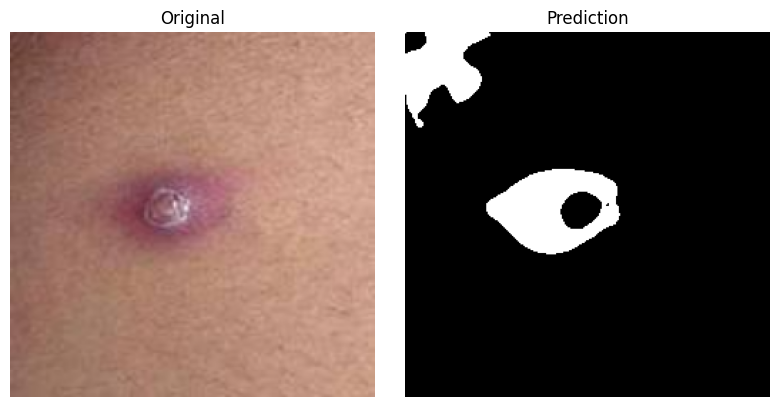

In [58]:
plt.figure(figsize=(12, 4))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(img_resized)
plt.title('Original')
plt.axis('off')


# Predicted mask
plt.subplot(1, 3, 2)
plt.imshow(pred_mask, cmap='gray')
plt.title('Prediction')
plt.axis('off')

plt.tight_layout()
plt.show()

In [61]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def vit_block(x, num_patches, projection_dim, transformer_layers=1, num_heads=4):
    # Flatten patches, add position embedding
    x = layers.Reshape((num_patches, -1))(x)
    pos_emb = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)
    positions = tf.range(start=0, limit=num_patches, delta=1)
    x = x + pos_emb(positions)
    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim)(x1, x1)
        x2 = layers.Add()([attention_output, x])
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = layers.Dense(projection_dim * 2, activation='gelu')(x3)
        x3 = layers.Dense(projection_dim, activation='gelu')(x3)
        x = layers.Add()([x2, x3])
    return x

def unet_vit(input_shape=(256, 256, 3), num_classes=1):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)  # 128x128
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)  # 128x128

    # ViT bottleneck: Extract patches from 128x128 feature map
    patch_size = 16
    projection_dim = 64
    num_patches = (input_shape[0] // 2 // patch_size) ** 2  # 128x128 input to ViT, 8x8 patches
    patches = layers.Conv2D(projection_dim, patch_size, strides=patch_size, padding='valid')(c2)  # (8,8,64)
    patches_flat = layers.Reshape((num_patches, projection_dim))(patches)
    vit_out = vit_block(patches_flat, num_patches, projection_dim)
    vit_out_reshaped = layers.Reshape((input_shape[0]//2//patch_size, input_shape[1]//2//patch_size, projection_dim))(vit_out)

    # Decoder (upsample to match c1)
    u1 = layers.UpSampling2D(size=(32, 32))(vit_out_reshaped)  # (256, 256, 64)
    u1 = layers.concatenate([u1, c1])
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)
    outputs = layers.Conv2D(num_classes, 1, activation='sigmoid')(c3)
    return keras.Model(inputs, outputs)

# Build and compile the model
model = unet_vit(input_shape=(256, 256, 3), num_classes=1)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=10  # Adjust as needed
)

Epoch 1/10


2025-07-01 06:08:16.129584: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f32[64,8,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,64,16,16]{3,2,1,0}, f32[8,64,113,113]{3,2,1,0}), window={size=113x113 pad=112_112x112_112 rhs_reversal=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-07-01 06:09:40.494721: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1m25.365266535s
Trying algorithm eng0{} for conv (f32[64,8,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,64,16,16]{3,2,1,0}, f32[8,64,113,113]{3,2,1,0}), window={size=113x113 pad=112_112x112_112 rhs_reversal=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", ba

 17/109 ━━━━━━━━━━━━━━━━━━━━ 17s 194ms/step - accuracy: 0.8153 - loss: 0.5329

2025-07-01 06:09:49.567283: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f32[64,5,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,64,16,16]{3,2,1,0}, f32[5,64,113,113]{3,2,1,0}), window={size=113x113 pad=112_112x112_112 rhs_reversal=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-07-01 06:10:41.994312: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 53.427153965s
Trying algorithm eng0{} for conv (f32[64,5,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,64,16,16]{3,2,1,0}, f32[5,64,113,113]{3,2,1,0}), window={size=113x113 pad=112_112x112_112 rhs_reversal=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", back

109/109 ━━━━━━━━━━━━━━━━━━━━ 181s 785ms/step - accuracy: 0.8639 - loss: 0.3616 - val_accuracy: 0.9133 - val_loss: 0.2285
Epoch 2/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 232ms/step - accuracy: 0.9089 - loss: 0.2222 - val_accuracy: 0.8973 - val_loss: 0.2875
Epoch 3/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 24s 223ms/step - accuracy: 0.9053 - loss: 0.2325 - val_accuracy: 0.9294 - val_loss: 0.1812
Epoch 4/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 26s 236ms/step - accuracy: 0.9205 - loss: 0.1923 - val_accuracy: 0.9300 - val_loss: 0.1678
Epoch 5/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 230ms/step - accuracy: 0.9317 - loss: 0.1663 - val_accuracy: 0.9376 - val_loss: 0.1566
Epoch 6/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 26s 233ms/step - accuracy: 0.9227 - loss: 0.1888 - val_accuracy: 0.9311 - val_loss: 0.1623
Epoch 7/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 226ms/step - accuracy: 0.9270 - loss: 0.1723 - val_accuracy: 0.9356 - val_loss: 0.1561
Epoch 8/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 26s 239ms/step - accuracy: 0.9284 - loss: 0.1655 - va

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 963ms/step


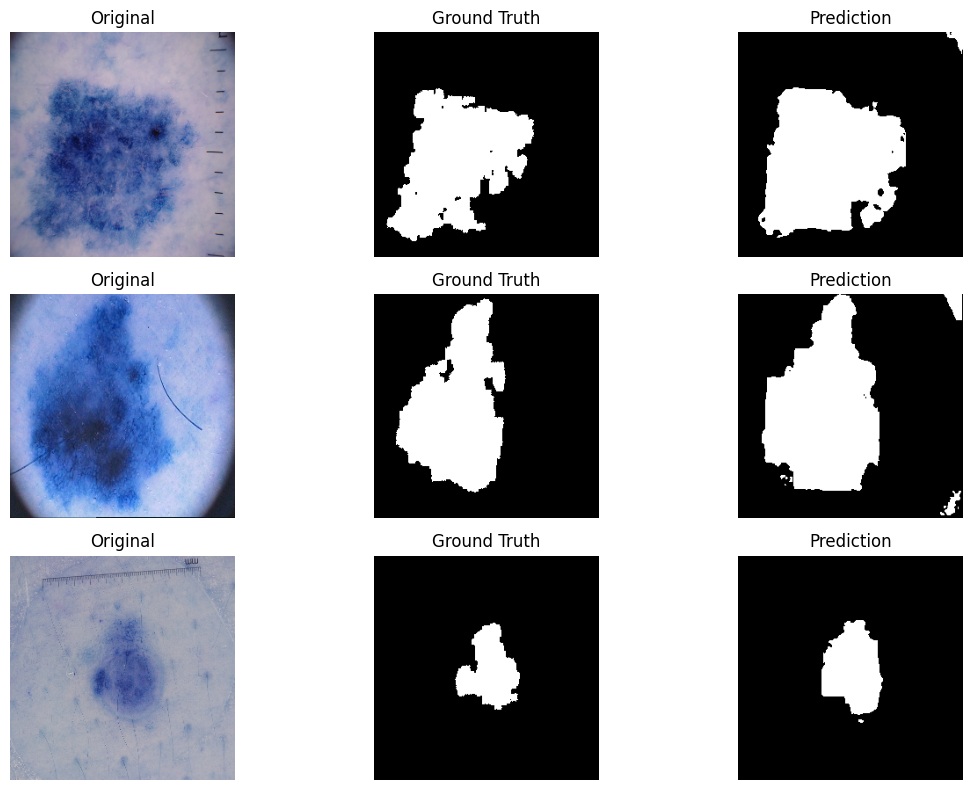

In [62]:
import matplotlib.pyplot as plt

X_val, Y_val = test_gen[0]  # Get a batch from validation

preds = model.predict(X_val)
preds = (preds > 0.5).astype(np.uint8)

plt.figure(figsize=(12, 8))
for i in range(3):
    plt.subplot(3, 3, 3*i+1)
    plt.imshow(X_val[i])
    plt.title('Original')
    plt.axis('off')
    plt.subplot(3, 3, 3*i+2)
    plt.imshow(Y_val[i].squeeze(), cmap='gray')
    plt.title('Ground Truth')
    plt.axis('off')
    plt.subplot(3, 3, 3*i+3)
    plt.imshow(preds[i].squeeze(), cmap='gray')
    plt.title('Prediction')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [81]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

def conv_block(input_tensor, num_filters):
    x = layers.Conv2D(num_filters, 3, padding="same", activation="relu")(input_tensor)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(num_filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    return x

def upsample_concat_block(input_tensor, skip_tensor, num_filters):
    x = layers.UpSampling2D((2, 2))(input_tensor)
    x = layers.Concatenate()([x, skip_tensor])
    x = conv_block(x, num_filters)
    return x

def build_resnet50_unet(input_shape=(256, 256, 3), num_classes=1):
    # Pre-trained ResNet50 as encoder
    base_model = keras.applications.ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
    # Skip connections
    c1 = base_model.get_layer("conv1_relu").output      # 128x128
    c2 = base_model.get_layer("conv2_block3_out").output # 64x64
    c3 = base_model.get_layer("conv3_block4_out").output # 32x32
    c4 = base_model.get_layer("conv4_block6_out").output # 16x16
    c5 = base_model.get_layer("conv5_block3_out").output # 8x8

    # Bridge
    b0 = conv_block(c5, 512)

    # Decoder
    d1 = upsample_concat_block(b0, c4, 512)   # 16x16
    d2 = upsample_concat_block(d1, c3, 256)   # 32x32
    d3 = upsample_concat_block(d2, c2, 128)   # 64x64
    d4 = upsample_concat_block(d3, c1, 64)    # 128x128

    # Final upsample to original size
    u = layers.UpSampling2D((2, 2))(d4)       # 256x256
    outputs = layers.Conv2D(num_classes, (1, 1), padding="same", activation="sigmoid")(u)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model

# Example usage:
if __name__ == '__main__':
    model = build_resnet50_unet(input_shape=(256, 256, 3), num_classes=1)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12            │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 262, 262, 3)    │              0 │ input_layer_12[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 128, 128, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 128, 128, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 128, 128, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 130, 130, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 64, 64, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 64, 64, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 64, 64, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 64, 64, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 64, 64, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 64, 64, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 64, 64, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 64, 64, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 64, 64, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 48,670,017 (185.66 MB)

 Trainable params: 48,611,009 (185.44 MB)

 Non-trainable params: 59,008 (230.50 KB)

In [82]:
# Train the model
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=10  # Adjust as needed
)

Epoch 1/10
  4/109 ━━━━━━━━━━━━━━━━━━━━ 21s 205ms/step - accuracy: 0.6257 - loss: 0.7539

E0000 00:00:1751352235.961708     121 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1751352236.220405     121 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.8676 - loss: 0.4016

E0000 00:00:1751352294.902072     120 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1751352295.158506     120 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


109/109 ━━━━━━━━━━━━━━━━━━━━ 163s 648ms/step - accuracy: 0.8679 - loss: 0.4009 - val_accuracy: 0.8290 - val_loss: 0.8605
Epoch 2/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 28s 254ms/step - accuracy: 0.9140 - loss: 0.2539 - val_accuracy: 0.8290 - val_loss: 0.5601
Epoch 3/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 28s 257ms/step - accuracy: 0.9296 - loss: 0.2020 - val_accuracy: 0.8290 - val_loss: 0.7238
Epoch 4/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 28s 259ms/step - accuracy: 0.9264 - loss: 0.2068 - val_accuracy: 0.8290 - val_loss: 0.8211
Epoch 5/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 28s 252ms/step - accuracy: 0.9270 - loss: 0.1931 - val_accuracy: 0.8290 - val_loss: 0.8997
Epoch 6/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 28s 259ms/step - accuracy: 0.9387 - loss: 0.1556 - val_accuracy: 0.8290 - val_loss: 0.7193
Epoch 7/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 28s 258ms/step - accuracy: 0.9380 - loss: 0.1580 - val_accuracy: 0.8359 - val_loss: 0.6349
Epoch 8/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 28s 258ms/step - accuracy: 0.9390 - loss: 0.1534 - va

In [87]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

def build_deeplabv3(input_shape=(256, 256, 3), num_classes=1):
    base_model = keras.applications.DenseNet121(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )

    # DeeplabV3-style ASPP
    x = base_model.output
    b0 = layers.Conv2D(256, 1, padding="same", activation="relu")(x)
    b1 = layers.Conv2D(256, 3, padding="same", dilation_rate=6, activation="relu")(x)
    b2 = layers.Conv2D(256, 3, padding="same", dilation_rate=12, activation="relu")(x)
    b3 = layers.Conv2D(256, 3, padding="same", dilation_rate=18, activation="relu")(x)
    b4 = layers.GlobalAveragePooling2D()(x)
    b4 = layers.Reshape((1, 1, b4.shape[-1]))(b4)
    b4 = layers.Conv2D(256, 1, padding="same", activation="relu")(b4)
    b4 = layers.UpSampling2D(
        size=(x.shape[1] // b4.shape[1], x.shape[2] // b4.shape[2]), interpolation="bilinear"
    )(b4)

    aspp = layers.Concatenate()([b0, b1, b2, b3, b4])
    aspp = layers.Conv2D(256, 1, padding="same", activation="relu")(aspp)
    aspp = layers.BatchNormalization()(aspp)
    aspp = layers.Dropout(0.5)(aspp)
    aspp = layers.UpSampling2D(
        size=(input_shape[0] // aspp.shape[1], input_shape[1] // aspp.shape[2]),
        interpolation="bilinear"
    )(aspp)

    outputs = layers.Conv2D(num_classes, 1, padding="same", activation="sigmoid")(aspp)
    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model

# Example usage:
if __name__ == '__main__':
    model = build_deeplabv3(input_shape=(256, 256, 3), num_classes=1)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15            │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d            │ (None, 262, 262, 3)    │              0 │ input_layer_15[0][0]   │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 128, 128, 64)   │          9,408 │ zero_padding2d[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 128, 128, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 128, 128, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_1          │ (None, 130, 130, 64)   │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 64, 64, 64)     │              0 │ zero_padding2d_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 64, 64, 64)     │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 64, 64, 64)     │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 64, 64, 128)    │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 64, 64, 128)    │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 64, 64, 128)    │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 64, 64, 32)     │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 64, 64, 96)     │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├──────────────────────

 Total params: 14,970,177 (57.11 MB)

 Trainable params: 14,886,017 (56.79 MB)

 Non-trainable params: 84,160 (328.75 KB)

In [88]:
# Train the model
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=10  # Adjust as needed
)

Epoch 1/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 321s 1s/step - accuracy: 0.8430 - loss: 0.4555 - val_accuracy: 0.8965 - val_loss: 0.2899
Epoch 2/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 27s 245ms/step - accuracy: 0.9283 - loss: 0.1923 - val_accuracy: 0.9248 - val_loss: 0.1891
Epoch 3/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 28s 253ms/step - accuracy: 0.9364 - loss: 0.1581 - val_accuracy: 0.9337 - val_loss: 0.1726
Epoch 4/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 28s 254ms/step - accuracy: 0.9404 - loss: 0.1484 - val_accuracy: 0.9346 - val_loss: 0.1731
Epoch 5/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 27s 249ms/step - accuracy: 0.9484 - loss: 0.1283 - val_accuracy: 0.9185 - val_loss: 0.2449
Epoch 6/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 27s 248ms/step - accuracy: 0.9421 - loss: 0.1428 - val_accuracy: 0.9384 - val_loss: 0.1588
Epoch 7/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 26s 239ms/step - accuracy: 0.9455 - loss: 0.1357 - val_accuracy: 0.9386 - val_loss: 0.1528
Epoch 8/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 27s 251ms/step - accuracy: 0.9483 - loss: 0.1

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


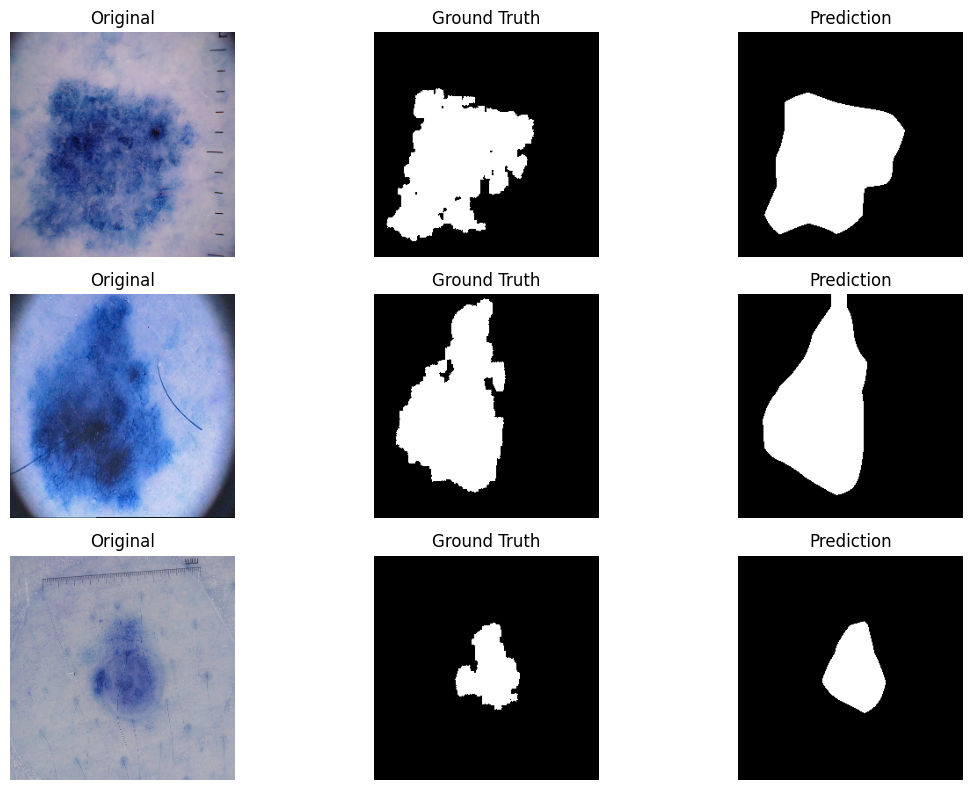

In [89]:
import matplotlib.pyplot as plt

X_val, Y_val = test_gen[0]  # Get a batch from validation

preds = model.predict(X_val)
preds = (preds > 0.5).astype(np.uint8)

plt.figure(figsize=(12, 8))
for i in range(3):
    plt.subplot(3, 3, 3*i+1)
    plt.imshow(X_val[i])
    plt.title('Original')
    plt.axis('off')
    plt.subplot(3, 3, 3*i+2)
    plt.imshow(Y_val[i].squeeze(), cmap='gray')
    plt.title('Ground Truth')
    plt.axis('off')
    plt.subplot(3, 3, 3*i+3)
    plt.imshow(preds[i].squeeze(), cmap='gray')
    plt.title('Prediction')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [93]:
img_path = '/kaggle/input/ferererere/testing .jpg'
img_size = (256, 256)  # Use your model's input size

# Read and resize image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, img_size)
img_input = img_resized.astype(np.float32) / 255.0
img_input = np.expand_dims(img_input, axis=0)  # Shape: (1, H, W, 3)

In [94]:
# Predict using your trained model
pred_mask = model.predict(img_input)
pred_mask = (pred_mask[0, ..., 0] > 0.5).astype(np.uint8)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


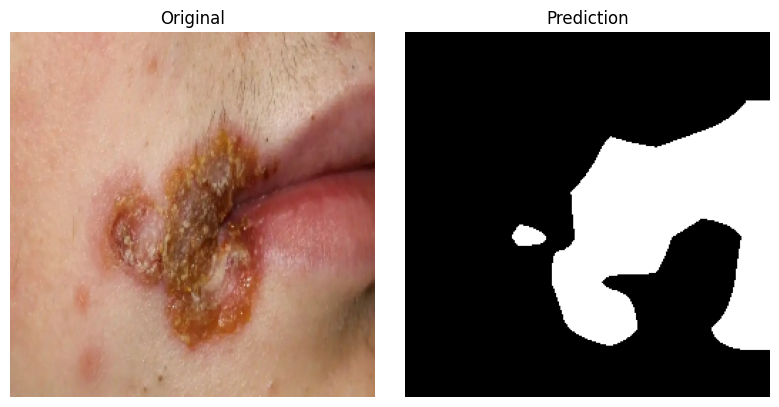

In [95]:
plt.figure(figsize=(12, 4))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(img_resized)
plt.title('Original')
plt.axis('off')


# Predicted mask
plt.subplot(1, 3, 2)
plt.imshow(pred_mask, cmap='gray')
plt.title('Prediction')
plt.axis('off')

plt.tight_layout()
plt.show()